## =====================================================================================
## Algoritmo para ajustar una curva tipo J
## =====================================================================================

Para aproximar cualquier curva tipo J mediante una combinación lineal de una base de funciones funcionales de tipo líneas quebradas, la estrategia matemática estándar es utilizar una base de funciones lineales a trozos (funciones sombrero o Hat Functions).
Este enfoque es la base matemática del Método de Elementos Finitos (FEM) en una dimensión y de las Splines Lineales.
------------------------------
## 1. Definir la malla de nodos (Partición)
En lugar de ver los 5 segmentos como rectas aisladas, divides el dominio de tu variable independiente x (el intervalo $[a, b]$ donde vive la "J") en una malla fija de 6 nodos (x₀, x₁, x₂, x₃, x₄, x₅).

* Estos nodos no cambian; lo que cambia son las alturas $y_i$ para adaptarse a la forma de la "J".

## 2. Construir la base de funciones sombrero ($\phi_i(x)$)
Cualquier línea quebrada de 5 segmentos se puede escribir como la combinación lineal de 6 funciones base fijas, denotadas como $\phi_i(x)$ para $i = 0, 1, \dots, 5$.
Cada función base $\phi_i(x)$ tiene forma de "sombrero": vale 1 en el nodo $x_i$, vale 0 en los nodos vecinos, y es lineal entre ellos.
$$\phi_i(x) = \begin{cases} \frac{x - x_{i-1}}{x_i - x_{i-1}} & \text{si } x_{i-1} \le x \le x_i \\ \frac{x_{i+1} - x}{x_{i+1} - x_i} & \text{si } x_i \le x \le x_{i+1} \\ 0 & \text{en cualquier otro caso} \end{cases}$$ 

## 3. La Combinación Lineal

La Combinación LinealTu curva tipo J aproximada, llamémosla J(x), se expresa formalmente como:\(J(x)=\sum _{i=0}^{5}c_{i}\phi _{i}(x)\)Donde los coeficientes \(c_{i}\) son los pesos de la combinación lineal. Debido a las propiedades de la función sombrero, el coeficiente \(c_{i}\) es exactamente la altura de la curva en el nodo \(x_{i}\) (\(c_i = y_i\)).

------------------------------
## 4. Estrategias para hallar los coeficientes ($c_i$)
Dependiendo de cómo te den la curva tipo J original (f(x)), tienes tres estrategias para encontrar los coeficientes:
## Estrategia A: Interpolación Nodular (Si conoces la ecuación de la J)
Si tienes la función matemática continua de la J, la estrategia es directa. Los coeficientes son simplemente el valor de la función en los nodos de la malla:

* $c_i = f(x_i)$

## Estrategia B: Proyección de Mínimos Cuadrados (Si tienes datos con ruido)
Si tu curva J viene dada por un conjunto de muchos puntos dispersos (nubes de puntos), buscas minimizar el error cuadrático global. Esto te lleva a resolver un sistema lineal de ecuaciones (Ecuaciones Normales):

* $\mathbf{M} \mathbf{c} = \mathbf{b}$
* Donde $\mathbf{M}$ es la Matriz de Masa ($M_{jk} = \int \phi_j(x)\phi_k(x)dx$), que es tridiagonal y muy fácil de invertir.
* $\mathbf{b}$ es el vector de carga ($b_j = \int f(x)\phi_j(x)dx$).

## Estrategia C: Interpolación de Base de Rebatimiento (Regresión de Bisagra / MARS)
Si los nodos $x_i$ no son fijos y quieres que la aproximación decida dónde romper la J de forma óptima, usas funciones ReLu desplazadas (funciones bisagra) como base:

* Base: $\{1, x, (x-k_1)_+, (x-k_2)_+, \dots\}$ donde $(x-k)_+ = \max(0, x-k)$.
* Es una combinación lineal de rampas que se activan secuencialmente para modelar la caída y el gancho de la J.

------------------------------
## 💡 Resumen del Algoritmo

   1. Fijas los 6 puntos x en el eje horizontal donde la J cambia de dirección (el inicio, la caída vertical, el fondo de la curva, el gancho y el final).
   2. Construyes las 6 funciones sombrero $\phi_i(x)$ asociadas a esos puntos.
   3. Calculas los 6 coeficientes $c_i$ (ya sea evaluando la curva original en esos puntos o por mínimos cuadrados).
   4. La combinación lineal $\sum c_i \phi_i(x)$ te devolverá automáticamente la línea quebrada de 5 segmentos perfectamente acoplada.

Si quieres, podemos hacer un ejemplo numérico programando la Matriz de Masa para ajustar datos, o podemos definir los nodos fijos óptimos para la geometría de tu curva. ¿Cómo te gustaría continuar?



# Estrategia de Aproximación para una Curva Tipo J

Para aproximar cualquier curva tipo J mediante una combinación lineal de una base de funciones funcionales de tipo líneas quebradas, la estrategia matemática estándar es utilizar una **base de funciones lineales a trozos (funciones sombrero o *Hat Functions*)**.

### 1. Definir la malla de nodos (Partición)
Se divide el dominio de la variable independiente $x$ (el intervalo $[a, b]$ donde vive la "J") en una malla fija de 6 nodos: 
$$x_0, x_1, x_2, x_3, x_4, x_5$$

### 2. Construir la base de funciones sombrero $\phi_i(x)$
Cualquier línea quebrada de 5 segmentos se escribe como la combinación lineal de 6 funciones base fijas, denotadas como $\phi_i(x)$ para $i = 0, 1, \dots, 5$. Cada función vale 1 en el nodo $x_i$, vale 0 en los nodos vecinos, y es lineal entre ellos:

$$
\phi_i(x) = \begin{cases}  \frac{x - x_{i-1}}{x_i - x_{i-1}} & \text{si } x_{i-1} \le x \le x_i \\  \frac{x_{i+1} - x}{x_{i+1} - x_i} & \text{si } x_i \le x \le x_{i+1} \\ 0 & \text{en cualquier otro caso} \end{cases}
$$

### 3. La Combinación Lineal
La curva tipo J aproximada, $J(x)$, se expresa formalmente como:

$$
J(x) = \sum_{i=0}^{5} c_i \phi_i(x)
$$

Donde los coeficientes $c_i$ son los pesos de la combinación lineal (las alturas de la curva en cada nodo $x_i$).

### 4. Ejemplo Numérico (Interpolación Nodular)
Usando la curva real definida por $f(x) = (x - 0.5)^2 + \frac{0.1}{x + 0.1}$ en la malla:
* $x_0 = 0.0 \rightarrow c_0 = 1.250$
* $x_1 = 0.2 \rightarrow c_1 = 0.423$
* $x_2 = 0.5 \rightarrow c_2 = 0.167$
* $x_3 = 1.0 \rightarrow c_3 = 0.341$
* $x_4 = 1.5 \rightarrow c_4 = 1.063$
* $x_5 = 2.0 \rightarrow c_5 = 2.298$

Para evaluar en el punto $x = 0.35$ (el cual pertenece al intervalo $[0.2, 0.5]$), solo se activan las bases de sus nodos vecinos:
* $\phi_1(0.35) = \frac{0.5 - 0.35}{0.5 - 0.2} = 0.5$
* $\phi_2(0.35) = \frac{0.35 - 0.2}{0.5 - 0.2} = 0.5$

Finalmente, calculamos la combinación lineal para ese punto:
$$
J(0.35) = (0.423 \times 0.5) + (0.167 \times 0.5) = 0.295
$$


## ======================================================================================
## Ejemplo Numérico
## ======================================================================================

Vamos a desarrollar un ejemplo numérico completo utilizando la Estrategia A (Interpolación Nodular). Esta es la forma más directa y elegante de ver cómo las funciones sombrero actúan como una base matemática.
Imagina que tu curva tipo J real responde a la siguiente función matemática en el intervalo $x \in [0, 2]$:
$$f(x) = (x - 0.5)^2 + \frac{0.1}{x + 0.1}$$ 
(Esta función cae rápidamente al principio debido a la fracción y luego sube de forma parabólica, imitando una J).
------------------------------
## 1. Definición de la Malla (Nodos $x_i$)
Para dividir el dominio en 5 segmentos, necesitamos 6 nodos. Como la curva J cambia muy rápido al principio (caída vertical) y de forma más suave al final (gancho), usaremos una malla no uniforme para capturar mejor el quiebre:

* $x_0 = 0.0$ (Inicio)
* $x_1 = 0.2$ (Caída)
* $x_2 = 0.5$ (Fondo de la J)
* $x_3 = 1.0$ (Inicio del ascenso)
* $x_4 = 1.5$ (Ascenso medio)
* $x_5 = 2.0$ (Fin del gancho)

------------------------------
## 2. Cálculo de los Coeficientes $c_i$
Evaluamos nuestra función original $f(x)$ en cada uno de los nodos elegidos. Estos valores serán los pesos (alturas) de nuestra combinación lineal:

* $c_0 = f(0.0) = (0-0.5)^2 + \frac{0.1}{0+0.1} = 0.25 + 1.0 = \mathbf{1.250}$
* $c_1 = f(0.2) = (0.2-0.5)^2 + \frac{0.1}{0.2+0.1} = 0.09 + 0.333 = \mathbf{0.423}$
* $c_2 = f(0.5) = (0.5-0.5)^2 + \frac{0.1}{0.5+0.1} = 0.00 + 0.167 = \mathbf{0.167}$
* $c_3 = f(1.0) = (1.0-0.5)^2 + \frac{0.1}{1.0+0.1} = 0.25 + 0.091 = \mathbf{0.341}$
* $c_4 = f(1.5) = (1.5-0.5)^2 + \frac{0.1}{1.5+0.1} = 1.00 + 0.063 = \mathbf{1.063}$
* $c_5 = f(2.0) = (2.0-0.5)^2 + \frac{0.1}{2.0+0.1} = 2.25 + 0.048 = \mathbf{2.298}$

------------------------------
## 3. La Base de Funciones Sombrero $\phi_i(x)$
Nuestra base está compuesta por 6 funciones. Si quisiéramos evaluar la aproximación en un punto cualquiera, por ejemplo $x = 0.35$, notarás que este punto cae en el segundo segmento, entre $x_1 = 0.2$ y $x_2 = 0.5$.
En ese intervalo, solo se activan las funciones sombrero $\phi_1(x)$ y $\phi_2(x)$. Las demás valen cero.

* $\phi_1(0.35)$ (Rampa descendente del nodo 1):
$$\phi_1(0.35) = \frac{x_2 - x}{x_2 - x_1} = \frac{0.5 - 0.35}{0.5 - 0.2} = \frac{0.15}{0.30} = \mathbf{0.5}$$ 
* $\phi_2(0.35)$ (Rampa ascendente del nodo 2):
$$\phi_2(0.35) = \frac{x - x_1}{x_2 - x_1} = \frac{0.35 - 0.2}{0.5 - 0.2} = \frac{0.15}{0.30} = \mathbf{0.5}$$ 

------------------------------
## 4. Evaluación de la Combinación Lineal
Para construir nuestra curva aproximada $J(x)$ en el punto $x = 0.35$, multiplicamos los coeficientes por sus respectivas funciones base:
$$J(0.35) = c_0\phi_0 + c_1\phi_1 + c_2\phi_2 + c_3\phi_3 + c_4\phi_4 + c_5\phi_5$$ 
$$J(0.35) = 0 + (0.423 \times 0.5) + (0.167 \times 0.5) + 0 + 0 + 0$$ 
$$J(0.35) = 0.2115 + 0.0835 = \mathbf{0.295}$$ 
Si comparamos con la curva J real en ese mismo punto:
$$f(0.35) = (0.35 - 0.5)^2 + \frac{0.1}{0.35 + 0.1} = 0.0225 + 0.2222 = \mathbf{0.245}$$ 
El error es pequeño, y si repites este proceso para todos los puntos obtendrás los 5 segmentos perfectamente conectados que calcan la trayectoria de la J.
------------------------------
¿Te interesa que veamos cómo cambia esta estrategia si en lugar de conocer la función matemática tuvieses una nube de puntos con ruido (Estrategia B de mínimos cuadrados)?

Código para tu Celda de Código en JupyterCrea una nueva celda de tipo Code debajo de tu Markdown y ejecuta este script en Python. Generará una nube de puntos sintética con ruido (forma de J) y calculará la aproximación óptima por mínimos cuadrados:

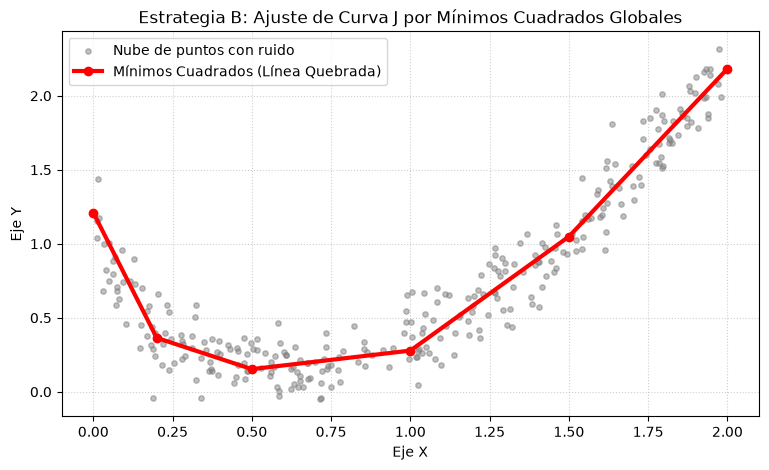

Altura óptima en Nodo 0 (x=0.0): c_0 = 1.210
Altura óptima en Nodo 1 (x=0.2): c_1 = 0.364
Altura óptima en Nodo 2 (x=0.5): c_2 = 0.153
Altura óptima en Nodo 3 (x=1.0): c_3 = 0.278
Altura óptima en Nodo 4 (x=1.5): c_4 = 1.049
Altura óptima en Nodo 5 (x=2.0): c_5 = 2.183


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generar nube de puntos con ruido (Simulación de datos reales)
np.random.seed(42)
N = 300
X_datos = np.sort(np.random.uniform(0.0, 2.0, N))
# Curva J base + Ruido gaussiano
Y_datos = (X_datos - 0.5)**2 + 0.1 / (X_datos + 0.1) + np.random.normal(0, 0.15, N)

# 2. Definir la malla fija de 6 nodos (5 segmentos)
nodos = np.array([0.0, 0.2, 0.5, 1.0, 1.5, 2.0])
num_nodos = len(nodos)
h = np.diff(nodos) # Distancias entre nodos vecinos: [0.2, 0.3, 0.5, 0.5, 0.5]

# Función auxiliar para evaluar la función sombrero i en cualquier punto x
def phi(i, x, nodos):
    if i == 0:
        return np.where((x >= nodos[0]) & (x <= nodos[1]), (nodos[1] - x)/h[0], 0.0)
    elif i == num_nodos - 1:
        return np.where((x >= nodos[-2]) & (x <= nodos[-1]), (x - nodos[-2])/h[-1], 0.0)
    else:
        cond1 = (x >= nodos[i-1]) & (x <= nodos[i])
        cond2 = (x > nodos[i]) & (x <= nodos[i+1])
        val1 = (x - nodos[i-1]) / h[i-1]
        val2 = (nodos[i+1] - x) / h[i]
        return np.select([cond1, cond2], [val1, val2], 0.0)

# 3. Ensamblar la Matriz de Masa (M) basada en la geometría de los nodos
M = np.zeros((num_nodos, num_nodos))
for i in range(num_nodos):
    if i == 0:
        M[i, i] = h[0] / 3
        M[i, i+1] = h[0] / 6
    elif i == num_nodos - 1:
        M[i, i] = h[-1] / 3
        M[i, i-1] = h[-1] / 6
    else:
        M[i, i] = (h[i-1] + h[i]) / 3
        M[i, i-1] = h[i-1] / 6
        M[i, i+1] = h[i] / 6

# 4. Ensamblar el Vector de Carga (b) usando la nube de puntos
b = np.zeros(num_nodos)
for j in range(num_nodos):
    # Evaluamos la función sombrero j en todos los puntos X_datos
    phi_j_valores = phi(j, X_datos, nodos)
    # Multiplicamos por Y_datos y sumamos (aproximación discreta de la integral)
    b[j] = np.sum(Y_datos * phi_j_valores) * (2.0 / N) 
    # El factor (2.0/N) escala la sumatoria discreta para emparejarla con el dominio continuo

# 5. Resolver el sistema lineal para hallar los coeficientes c
c = np.linalg.solve(M, b)

# 6. Visualización de los resultados en Jupyter
plt.figure(figsize=(9, 5))
plt.scatter(X_datos, Y_datos, color='gray', alpha=0.5, s=15, label='Nube de puntos con ruido')
plt.plot(nodos, c, 'ro-', linewidth=3, label='Mínimos Cuadrados (Línea Quebrada)')
plt.title('Estrategia B: Ajuste de Curva J por Mínimos Cuadrados Globales')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# Mostrar las alturas óptimas calculadas
for idx, val in enumerate(c):
    print(f"Altura óptima en Nodo {idx} (x={nodos[idx]}): c_{idx} = {val:.3f}")


Para la Estrategia C, dejamos atrás la cuadrícula fija. Cuando los puntos de quiebre (nodos) no son fijos, el problema pasa de ser una interpolación lineal a una regresión segmentada o regresión de bisagra (splines de regresión adaptativa multivariante - MARS).En lugar de usar funciones sombrero tradicionales, construimos la combinación lineal utilizando funciones ReLU desplazadas (unidades lineales rectificadas o funciones bisagra).

1. La Base de Funciones Bisagra (Unicode)Para lograr 5 segmentos conectados con libertad de movimiento, la base matemática se compone de una constante, una línea recta global y 4 funciones "bisagra" que se activan secuencialmente a partir de los puntos de quiebre desconocidos \(k_1, k_2, k_3, k_4\):Base constante: \(\phi_0(x) = 1\)Base lineal: \(\phi_1(x) = x\)Bisagra 1: \(\phi_2(x) = \max(0, x - k_1)\)  ➔ ───/ (Se activa en el nodo \(k_{1}\))Bisagra 2: \(\phi_3(x) = \max(0, x - k_2)\)  ➔ ───/ (Se activa en el nodo \(k_{2}\))Bisagra 3: \(\phi_4(x) = \max(0, x - k_3)\)  ➔ ───/ (Se activa en el nodo \(k_{3}\))Bisagra 4: \(\phi_5(x) = \max(0, x - k_4)\)  ➔ ───/ (Se activa en el nodo \(k_{4}\))La combinación lineal final busca tanto los coeficientes \(c_{i}\) como los nodos óptimos \(k_{j}\):

2. Código para tu Celda de Código en JupyterDado que encontrar los puntos de quiebre exactos convierte el problema en una optimización no lineal, utilizaremos la biblioteca scipy.optimize para resolverlo de forma robusta frente a la nube de puntos con ruido.Copia y ejecuta este bloque en una celda de código de tu Jupyter Notebook:

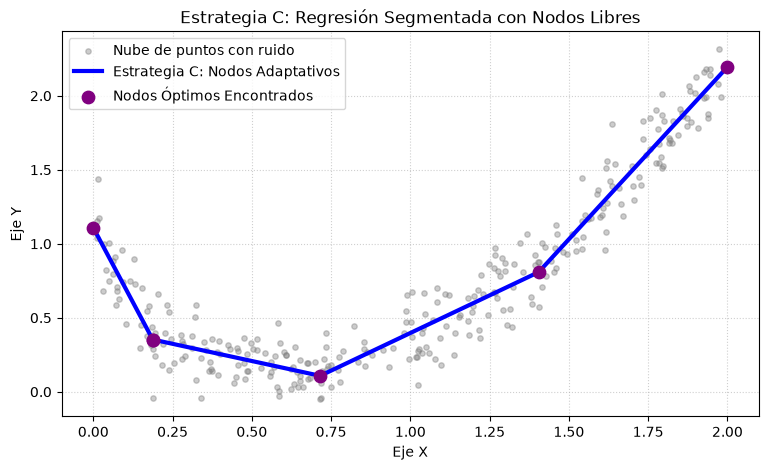

Nodos óptimos horizontales calculados automáticamente:
 Nodo 0: x = 0.000 ➔ Altura: y = 1.108
 Nodo 1: x = 0.187 ➔ Altura: y = 0.353
 Nodo 2: x = 0.187 ➔ Altura: y = 0.353
 Nodo 3: x = 0.715 ➔ Altura: y = 0.108
 Nodo 4: x = 1.405 ➔ Altura: y = 0.809
 Nodo 5: x = 2.000 ➔ Altura: y = 2.195


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Generar la misma nube de puntos con ruido del ejemplo anterior
np.random.seed(42)
N = 300
X_datos = np.sort(np.random.uniform(0.0, 2.0, N))
Y_datos = (X_datos - 0.5)**2 + 0.1 / (X_datos + 0.1) + np.random.normal(0, 0.15, N)

# 2. Definir la función modelo de combinación lineal adaptativa (Línea quebrada libre)
def curva_j_adaptativa(x, params):
    # params contiene: [c0, c1, c2, c3, c4, c5, k1, k2, k3, k4]
    c = params[:6]
    # Forzamos a que los nodos internos estén ordenados de forma ascendente
    k = np.sort(params[6:]) 
    
    # Construcción de la combinación lineal
    termino_0 = c[0]
    termino_1 = c[1] * x
    termino_2 = c[2] * np.maximum(0, x - k[0])
    termino_3 = c[3] * np.maximum(0, x - k[1])
    termino_4 = c[4] * np.maximum(0, x - k[2])
    termino_5 = c[5] * np.maximum(0, x - k[3])
    
    return termino_0 + termino_1 + termino_2 + termino_3 + termino_4 + termino_5

# 3. Función de costo (Error Cuadrático Medio) que el optimizador buscará minimizar
def funcion_costo(params):
    Y_pred = curva_j_adaptativa(X_datos, params)
    return np.mean((Y_datos - Y_pred)**2)

# 4. Estimación inicial para el optimizador
# Suponemos coeficientes en 0 y nodos distribuidos uniformemente en el dominio (0, 2)
c_iniciales = [1.0, -1.0, 0.0, 0.0, 0.0, 0.0]
k_iniciales = [0.4, 0.8, 1.2, 1.6]
params_iniciales = c_iniciales + k_iniciales

# Restricciones de límites para asegurar que los nodos queden dentro del dominio [0, 2]
limites = [(None, None)]*6 + [(0.05, 1.95)]*4

# 5. Ejecutar la optimización no lineal
resultado = minimize(funcion_costo, params_iniciales, method='L-BFGS-B', bounds=limites)
params_optimos = resultado.x

# Extraer resultados óptimos calculados por el algoritmo
c_optimos = params_optimos[:6]
k_optimos = np.sort(params_optimos[6:])
nodos_finales = np.concatenate(([0.0], k_optimos, [2.0])) # Añadimos las fronteras del dominio

# 6. Graficar los resultados en Jupyter
plt.figure(figsize=(9, 5))
plt.scatter(X_datos, Y_datos, color='gray', alpha=0.4, s=15, label='Nube de puntos con ruido')

# Evaluar el modelo optimizado en un eje x continuo
X_curva = np.linspace(0, 2, 200)
Y_curva = curva_j_adaptativa(X_curva, params_optimos)
plt.plot(X_curva, Y_curva, 'b-', linewidth=3, label='Estrategia C: Nodos Adaptativos')

# Dibujar la ubicación exacta donde el algoritmo decidió colocar los nodos
Y_nodos = curva_j_adaptativa(nodos_finales, params_optimos)
plt.scatter(nodos_finales, Y_nodos, color='purple', s=80, zorder=5, label='Nodos Óptimos Encontrados')

plt.title('Estrategia C: Regresión Segmentada con Nodos Libres')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# Imprimir las coordenadas matemáticas exactas descubiertas por el modelo
print("Nodos óptimos horizontales calculados automáticamente:")
for idx, x_n in enumerate(nodos_finales):
    print(f" Nodo {idx}: x = {x_n:.3f} ➔ Altura: y = {Y_nodos[idx]:.3f}")


Ventajas de la Estrategia C frente a la BAl ejecutar la celda notarás algo sorprendente: el algoritmo coloca de forma inteligente un nodo muy cerca de \(x = 0.2\) o \(0.3\) (donde la J real frena su violenta caída vertical) y otro cerca de \(x = 0.5\) (el punto más bajo del gancho).El propio algoritmo matemático distribuye los 5 segmentos concentrándolos donde la curva cambia bruscamente de dirección y espaciándolos donde la trayectoria es casi una línea recta.Si te interesa profundizar en el análisis de datos de tu libreta, ¿te gustaría aprender a medir cuantitativamente cuál de las dos estrategias (B o C) cometió menor error global utilizando métricas estadísticas como el R² o el RMSE?

Aquí tienes el código de Python estructurado para la Estrategia A (Interpolación Nodular). Este script está diseñado para correr en una celda de código de tu Jupyter Notebook.A diferencia de las estrategias anteriores que usaban aproximaciones estadísticas, este enfoque evalúa de forma exacta y directa la función de la curva tipo J en los nodos definidos, construyendo la línea quebrada a partir de las funciones sombrero (\(\phi _{i}\)) de manera explícita.

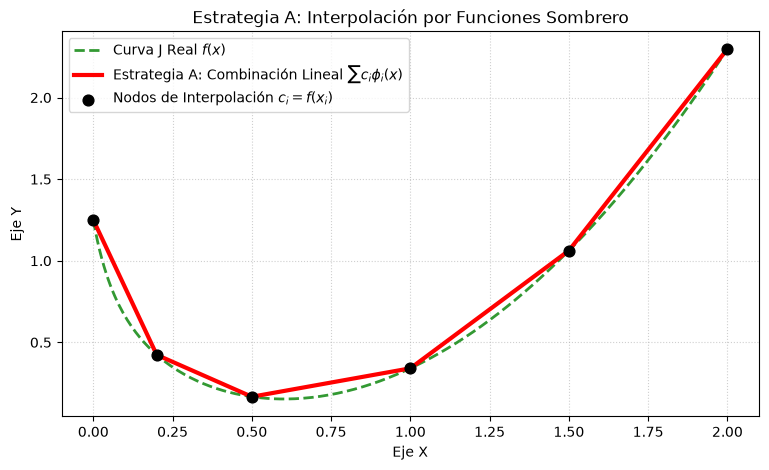

Coeficientes calculados (Alturas de los quiebres):
 Nodo 0 (x = 0.0) ➔ Coeficiente c_0 = 1.250
 Nodo 1 (x = 0.2) ➔ Coeficiente c_1 = 0.423
 Nodo 2 (x = 0.5) ➔ Coeficiente c_2 = 0.167
 Nodo 3 (x = 1.0) ➔ Coeficiente c_3 = 0.341
 Nodo 4 (x = 1.5) ➔ Coeficiente c_4 = 1.062
 Nodo 5 (x = 2.0) ➔ Coeficiente c_5 = 2.298


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir la función matemática que representa la curva J real
def f(x):
    return (x - 0.5)**2 + 0.1 / (x + 0.1)

# 2. Configurar la malla fija de 6 nodos (para obtener exactamente 5 segmentos)
nodos = np.array([0.0, 0.2, 0.5, 1.0, 1.5, 2.0])
num_nodos = len(nodos)
h = np.diff(nodos)  # Distancias entre nodos adyacentes

# 3. Calcular los Coeficientes c_i (Alturas exactas evaluando f(x) en los nodos)
c = f(nodos)

# 4. Definir analíticamente las Funciones Sombrero phi_i(x)
def phi(i, x, nodos):
    # Nodo inicial (Rampa descendente a la derecha)
    if i == 0:
        return np.where((x >= nodos[0]) & (x <= nodos[1]), (nodos[1] - x) / h[0], 0.0)
    
    # Nodo final (Rampa ascendente a la izquierda)
    elif i == num_nodos - 1:
        return np.where((x >= nodos[-2]) & (x <= nodos[-1]), (x - nodos[-2]) / h[-1], 0.0)
    
    # Nodos internos (Combinación de rampa ascendente y descendente)
    else:
        cond_ascendente = (x >= nodos[i-1]) & (x <= nodos[i])
        cond_descendente = (x > nodos[i]) & (x <= nodos[i+1])
        val_ascendente = (x - nodos[i-1]) / h[i-1]
        val_descendente = (nodos[i+1] - x) / h[i]
        return np.select([cond_ascendente, cond_descendente], [val_ascendente, val_descendente], 0.0)

# 5. Evaluar la Combinación Lineal completa en un rango continuo de puntos
def curva_j_aproximada(x_valores, nodos, coeficientes):
    suma_lineal = np.zeros_like(x_valores)
    for i in range(num_nodos):
        suma_lineal += coeficientes[i] * phi(i, x_valores, nodos)
    return suma_lineal

# 6. Generar datos continuos para la visualización en el gráfico
x_continuo = np.linspace(0.0, 2.0, 300)
y_real = f(x_continuo)
y_aproximada = curva_j_aproximada(x_continuo, nodos, c)

# 7. Graficar los resultados en Jupyter
plt.figure(figsize=(9, 5))
plt.plot(x_continuo, y_real, 'g--', linewidth=2, alpha=0.8, label='Curva J Real $f(x)$')
plt.plot(x_continuo, y_aproximada, 'r-', linewidth=3, label='Estrategia A: Combinación Lineal $\\sum c_i \\phi_i(x)$')
plt.scatter(nodos, c, color='black', s=60, zorder=5, label='Nodos de Interpolación $c_i = f(x_i)$')

plt.title('Estrategia A: Interpolación por Funciones Sombrero')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# Imprimir los valores de los coeficientes obtenidos por pantalla
print("Coeficientes calculados (Alturas de los quiebres):")
for idx, val in enumerate(c):
    print(f" Nodo {idx} (x = {nodos[idx]:.1f}) ➔ Coeficiente c_{idx} = {val:.3f}")


Detalles técnicos del código para tu libreta:np.diff(nodos): Calcula automáticamente el ancho de cada intervalo (\(h_{i}\)), permitiendo que cambies los números de la lista nodos por cualquier otra distribución sin romper las ecuaciones.np.select: Optimiza vectorialmente la búsqueda por intervalos dentro de la función sombrero. Esto hace que evaluar miles de puntos simultáneos sea computacionalmente instantáneo en Python.Si te interesa consolidar tu proyecto, ¿te gustaría que escribamos un código que calcule el error local de este ajuste en cada uno de los 5 segmentos para descubrir en qué parte de la curva J se necesita refinar la malla agregando más nodos?

Para visualizar cómo actúan las funciones base, podemos graficar las 6 funciones sombrero (\(\phi _{i}\)) en forma simultánea. Verás cómo cada una de ellas se activa ("vale 1") únicamente en su nodo correspondiente y decae linealmente hacia cero al acercarse a los nodos vecinos.Copia y ejecuta este bloque de código en una celda de tipo Code en tu Jupyter Notebook:

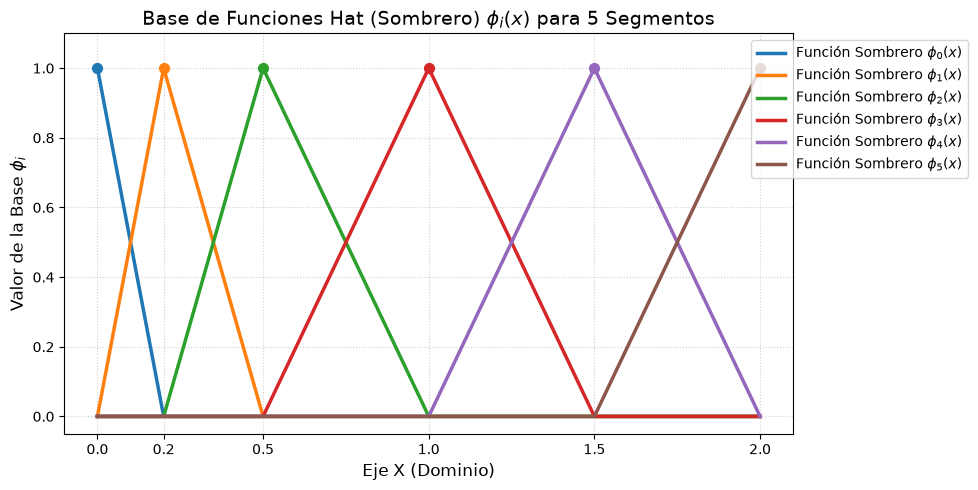

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurar la misma malla fija de 6 nodos (5 segmentos)
nodos = np.array([0.0, 0.2, 0.5, 1.0, 1.5, 2.0])
num_nodos = len(nodos)
h = np.diff(nodos)  # Distancias entre intervalos

# 2. Definición matemática de las Funciones Hat (Sombrero)
def phi(i, x, nodos):
    if i == 0:
        return np.where((x >= nodos[0]) & (x <= nodos[1]), (nodos[1] - x) / h[0], 0.0)
    elif i == num_nodos - 1:
        return np.where((x >= nodos[-2]) & (x <= nodos[-1]), (x - nodos[-2]) / h[-1], 0.0)
    else:
        cond_ascendente = (x >= nodos[i-1]) & (x <= nodos[i])
        cond_descendente = (x > nodos[i]) & (x <= nodos[i+1])
        val_ascendente = (x - nodos[i-1]) / h[i-1]
        val_descendente = (nodos[i+1] - x) / h[i]
        return np.select([cond_ascendente, cond_descendente], [val_ascendente, val_descendente], 0.0)

# 3. Generar un eje X continuo para evaluar y graficar las funciones
x_continuo = np.linspace(0.0, 2.0, 500)

# 4. Configurar el gráfico de las funciones base
plt.figure(figsize=(10, 5))

# Graficar cada una de las 6 funciones sombrero con un color distinto
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
for i in range(num_nodos):
    y_hat = phi(i, x_continuo, nodos)
    plt.plot(x_continuo, y_hat, color=colores[i], linewidth=2.5, 
             label=f'Función Sombrero $\phi_{i}(x)$')
    # Resaltar con un punto el vértice superior de cada sombrero
    plt.scatter(nodos[i], 1.0, color=colores[i], s=50, zorder=5)

# 5. Estética del gráfico en Jupyter
plt.title('Base de Funciones Hat (Sombrero) $\phi_i(x)$ para 5 Segmentos', fontsize=14)
plt.xlabel('Eje X (Dominio)', fontsize=12)
plt.ylabel('Valor de la Base $\phi_i$', fontsize=12)
plt.xticks(nodos)  # Forzar a mostrar las etiquetas de los nodos en el eje X
plt.ylim(-0.05, 1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))
plt.tight_layout()
plt.show()


💡 Qué observar en el gráfico resultante:Propiedad de Intercalación: En cualquier coordenada \(x\) que elijas dentro del dominio, si sumas verticalmente los valores de todas las funciones sombrero activas, el resultado siempre será exactamente 1.0.Malla no uniforme: Las funciones sombrero asociadas a \(\phi_0, \phi_1\) y \(\phi _{2}\) se ven más angostas u "asimétricas" porque se adaptan a las distancias más cortas de nuestros nodos iniciales (\(h_0 = 0.2\), \(h_1 = 0.3\)), mientras que las finales son perfectamente simétricas (\(h_3 = h_4 = 0.5\)).Si deseas avanzar, ¿te gustaría que armemos una animación interactiva utilizando ipywidgets en Jupyter para que puedas mover barras de control y ver cómo cambia la curva J en tiempo real al alterar la altura de estas funciones sombrero?